# Imports

In [1]:
import os
import h5py
import torch
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoModel
from torchvision import transforms
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from huggingface_hub import login

# Markdown

In [2]:
DATA_DIR  = "./data/"
N_SAMPLES = 500
HF_TOKEN  = open("token.txt").read()

login(token=HF_TOKEN)

# ROI Map

In [3]:
V1_MNI = np.array([8, -84, 2])

# Name, name of the file for this ROI, list of label IDs in the atlas, MNI coordinates (for distance to V1), color for plots
NSD_ROI_MAP = {
    "V1":  ("prf-visualrois.nii.gz", [1, 2], np.array([8,  -84,   2]), "#1f77b4"),
    "V2":  ("prf-visualrois.nii.gz", [3, 4], np.array([8,  -80,  10]), "#ff7f0e"),
    "V3":  ("prf-visualrois.nii.gz", [5, 6], np.array([10, -74,  16]), "#2ca02c"),
    "hV4": ("prf-visualrois.nii.gz", [7],    np.array([28, -64,  -8]), "#d62728"),
    "OFA": ("floc-faces.nii.gz",     [1],    np.array([38, -76, -12]), "#9467bd"),
    "FFA": ("floc-faces.nii.gz",     [2, 3], np.array([40, -52, -14]), "#e377c2"),
    "OPA": ("floc-places.nii.gz",    [1],    np.array([36, -76,  30]), "#7f7f7f"),
    "PPA": ("floc-places.nii.gz",    [3],    np.array([26, -46, -10]), "#bcbd22"),
    "EBA": ("floc-bodies.nii.gz",    [1],    np.array([46, -66,   2]), "#8c564b"),
    "IPS": ("streams.nii.gz",        [7],    np.array([24, -60,  54]), "#17becf"),
}

# Calcul des distances de chaque ROI à V1
ROI_DIST_TO_V1 = {
    name: float(np.linalg.norm(info[2] - V1_MNI))
    for name, info in NSD_ROI_MAP.items()
}

# Affichage
print("Distances à V1")
for name, d in ROI_DIST_TO_V1.items():
    print(f"{name} : {d} mm")


def load_roi_masks_nsd(roi_map, roi_dir, brain_shape):
    masks = {}
    atlas_cache = {}

    for roi_name, (atlas_file, label_ids, _, _) in roi_map.items(): # On parcourt les ROIs
        atlas_path = os.path.join(roi_dir, atlas_file)

        if not os.path.exists(atlas_path): # Vérifie que le fichier existe
            raise FileNotFoundError(f"Atlas file not found: {atlas_path}")

        if atlas_file not in atlas_cache: # Vérifie si l'atlas a déjà été chargé
            raw = nib.load(atlas_path).get_fdata().astype(int)
            if raw.shape != brain_shape: # Vérifie que la forme de l'atlas correspond à celle du cerveau
                raise ValueError(
                    f"Shape mismatch pour {atlas_file} : "
                    f"atlas={raw.shape}, attendu={brain_shape}"
                )
            atlas_cache[atlas_file] = raw # Met en cache les données

        atlas_data = atlas_cache[atlas_file] # Récupère les données de l'atlas depuis le cache
        mask = np.zeros(brain_shape, dtype=bool)
        for lbl in label_ids:
            mask |= (atlas_data == lbl) # Crée un masque binaire pour les labels de la ROI

        n_vox = mask.sum()
        print(f"{roi_name}: {n_vox} voxels (labels={label_ids} | {atlas_file})")

        masks[roi_name] = mask

    return masks


Distances à V1
V1 : 0.0 mm
V2 : 8.94427190999916 mm
V3 : 17.320508075688775 mm
hV4 : 30.0 mm
OFA : 34.058772731852805 mm
FFA : 48.0 mm
OPA : 40.39801975344831 mm
PPA : 43.726422218150894 mm
EBA : 42.04759208325728 mm
IPS : 59.464274989274024 mm


# Chargement des volumes fMRI

In [4]:
index = pd.read_csv(DATA_DIR + "trial_index.csv") # L'index contient les colonnes : subject, session, trial_in_session, global_trial, nsd_stim_id, is_shared_1000, file_path
print(f"  {len(index)} trials disponibles, on charge {min(N_SAMPLES, len(index))}")

fmri_volumes = [] # Liste pour stocker les tenseurs fMRI
stim_ids     = [] # Liste pour stocker les IDs des stimuli

for i in range(min(N_SAMPLES, len(index))):
    row = index.iloc[i]
    nii = nib.load(DATA_DIR + row["file_path"]) 
    data = nii.get_fdata(dtype=np.float32)
    fmri_volumes.append(torch.tensor(data))
    stim_ids.append(int(row["nsd_stim_id"]))
    if i % 100 == 0:
        print(f"{i}/{N_SAMPLES}")

fmri_tensor = torch.stack(fmri_volumes, dim=0)
BRAIN_SHAPE = tuple(fmri_tensor.shape[1:])
print(f"fMRI tensor shape : {fmri_tensor.shape} - BRAIN_SHAPE={BRAIN_SHAPE}")


  213000 trials disponibles, on charge 500
0/500
100/500
200/500
300/500
400/500
fMRI tensor shape : torch.Size([500, 81, 104, 83]) - BRAIN_SHAPE=(81, 104, 83)


# Extraction des features DINO

In [5]:
model  = AutoModel.from_pretrained(
    "facebook/dinov3-vits16-pretrain-lvd1689m",
    output_hidden_states=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval().to(device)
print(f"  Device : {device}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Extraction des features DINO")
all_layer_features = np.zeros((12, len(stim_ids), 384), dtype=np.float32) # Tableau pour stocker les features de toutes les couches

with h5py.File(DATA_DIR + "nsd_stimuli.hdf5", "r") as f_stim: # Le fichier contenant les images des stimuli
    with torch.no_grad():
        for idx, stim_id in enumerate(stim_ids):
            image_np = f_stim["imgBrick"][stim_id] # Récupère l'image du stimulus à partir de son ID
            img_tensor = transform(Image.fromarray(image_np)).unsqueeze(0).to(device)
            hidden = model(img_tensor).hidden_states # Passe l'image dans DINO et récupère les états des couches

            layer_feats = torch.stack([h[0, 0, :].cpu() for h in hidden[1:]], dim=0) # On ignore la couche d'entrée et on prend le token CLS pour chaque couche

            all_layer_features[:, idx, :] = layer_feats.numpy() 

            if idx % 100 == 0:
                print(f"Image {idx}/{len(stim_ids)}")

print(f"Features DINO : {all_layer_features.shape}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Device : cuda
Extraction des features DINO
Image 0/500
Image 100/500
Image 200/500
Image 300/500
Image 400/500
Features DINO : (12, 500, 384)


# Masques ROI

In [6]:
roi_dir = os.path.join(DATA_DIR, "roi_masks", "subj01")
roi_masks = load_roi_masks_nsd(NSD_ROI_MAP, roi_dir, BRAIN_SHAPE)
roi_names = list(NSD_ROI_MAP.keys())

V1: 1350 voxels (labels=[1, 2] | prf-visualrois.nii.gz)
V2: 1433 voxels (labels=[3, 4] | prf-visualrois.nii.gz)
V3: 1187 voxels (labels=[5, 6] | prf-visualrois.nii.gz)
hV4: 687 voxels (labels=[7] | prf-visualrois.nii.gz)
OFA: 355 voxels (labels=[1] | floc-faces.nii.gz)
FFA: 794 voxels (labels=[2, 3] | floc-faces.nii.gz)
OPA: 1611 voxels (labels=[1] | floc-places.nii.gz)
PPA: 566 voxels (labels=[3] | floc-places.nii.gz)
EBA: 2971 voxels (labels=[1] | floc-bodies.nii.gz)
IPS: 3548 voxels (labels=[7] | streams.nii.gz)


# Ridge train et eval

In [7]:
def train_ridge_encoding(X, Y): # Entraine un modèle de régression RidgeCV et retourne le Pearson r sur le test set
    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.15, random_state=42)
    clf   = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10]).fit(X_tr, Y_tr)
    preds = clf.predict(X_te)
    r, _ = pearsonr(preds, Y_te)
    return float(r)


# Encoding scores

In [8]:
# Calcule le encoding score pour chaque ROI et chaque couche. Il représente la capacité à prédire la réponse de la ROI à partir des features de la couche au même stimulus.

encoding_scores = np.zeros((len(roi_names), 12))
fmri_np = fmri_tensor.numpy()

for ri, roi_name in enumerate(roi_names):
    mask = roi_masks[roi_name]
    roi_response = fmri_np[:, mask].mean(axis=1)

    for li in range(12):
        encoding_scores[ri, li] = train_ridge_encoding(all_layer_features[li], roi_response) # Entraine un modèle de régression pour chaque couche et stocke le score

    best_li = encoding_scores[ri].argmax()
    print(f"{roi_name}: best layer = L{best_li+1}"f"(r={encoding_scores[ri, best_li]})")



V1: best layer = L3(r=0.5392191410064697)
V2: best layer = L4(r=0.5017306804656982)
V3: best layer = L4(r=0.4247191250324249)
hV4: best layer = L3(r=0.41361886262893677)
OFA: best layer = L1(r=0.3019716441631317)
FFA: best layer = L8(r=0.275760293006897)
OPA: best layer = L12(r=0.11260192096233368)
PPA: best layer = L6(r=0.39896783232688904)
EBA: best layer = L9(r=0.3692682683467865)
IPS: best layer = L12(r=0.06809277832508087)


# Spatial score

In [9]:
# Calcule le spatial score : corrélation entre la distance à V1 et la couche optimale de prédiction pour chaque ROI
# C'est un indicateur de similarité entre l'organisation hiérarchique du modèle et celle du cerveau.

k_star = encoding_scores.argmax(axis=1)
k_star_norm = k_star / (12 - 1)
d_star = np.array([ROI_DIST_TO_V1[r] for r in roi_names])

spatial_score, p_value = pearsonr(d_star, k_star_norm)
print(f"Spatial score = {spatial_score:.4f}   (p = {p_value:.4f})")
print("Détail par ROI :")
for ri, roi in enumerate(roi_names):
    print(f"{roi} | d* = {d_star[ri]} mm | "f"k* = L{k_star[ri]+1} ({k_star_norm[ri]}) | "f"best r = {encoding_scores[ri].max()}")

Spatial score = 0.6847   (p = 0.0289)
Détail par ROI :
V1 | d* = 0.0 mm | k* = L3 (0.18181818181818182) | best r = 0.5392191410064697
V2 | d* = 8.94427190999916 mm | k* = L4 (0.2727272727272727) | best r = 0.5017306804656982
V3 | d* = 17.320508075688775 mm | k* = L4 (0.2727272727272727) | best r = 0.4247191250324249
hV4 | d* = 30.0 mm | k* = L3 (0.18181818181818182) | best r = 0.41361886262893677
OFA | d* = 34.058772731852805 mm | k* = L1 (0.0) | best r = 0.3019716441631317
FFA | d* = 48.0 mm | k* = L8 (0.6363636363636364) | best r = 0.275760293006897
OPA | d* = 40.39801975344831 mm | k* = L12 (1.0) | best r = 0.11260192096233368
PPA | d* = 43.726422218150894 mm | k* = L6 (0.45454545454545453) | best r = 0.39896783232688904
EBA | d* = 42.04759208325728 mm | k* = L9 (0.7272727272727273) | best r = 0.3692682683467865
IPS | d* = 59.464274989274024 mm | k* = L12 (1.0) | best r = 0.06809277832508087


# Visualization

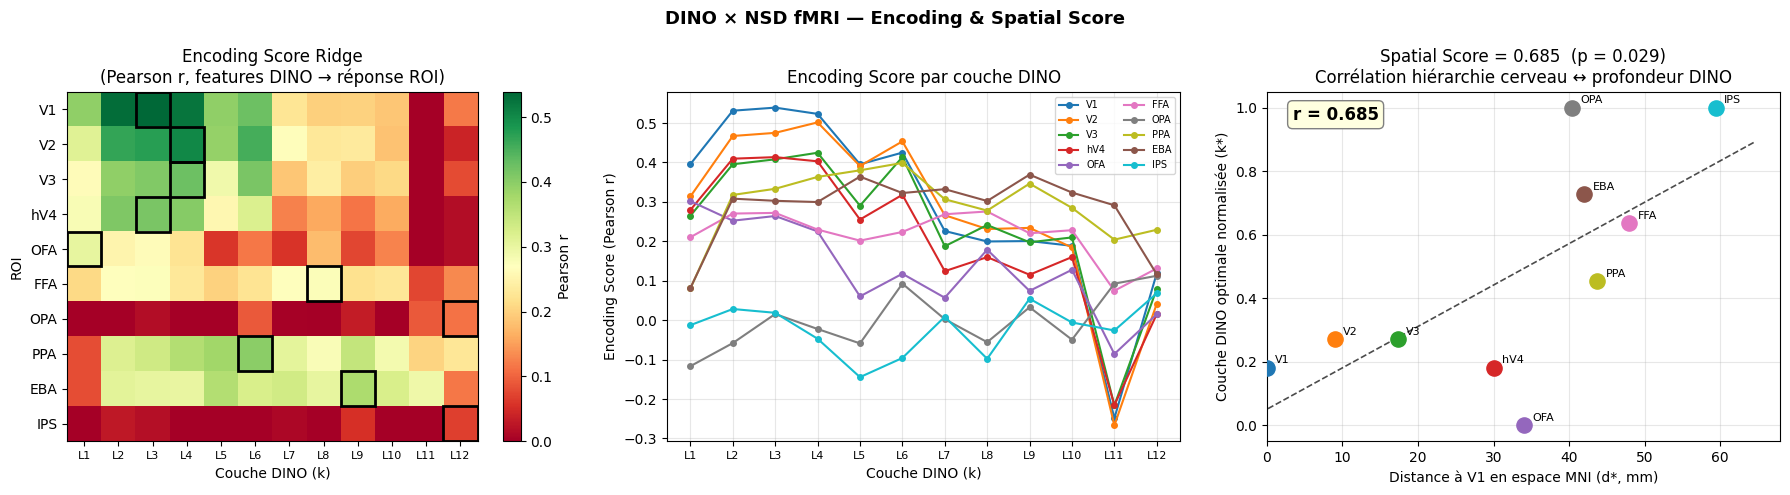

Figure sauvegardée : fmri_spatial_score.png


In [10]:

roi_colors   = [NSD_ROI_MAP[r][3] for r in roi_names]
layer_ticks  = np.arange(12)
layer_labels = [f"L{i+1}" for i in range(12)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Heatmap encoding scores (ROI × couche)
ax = axes[0]
im = ax.imshow(encoding_scores, aspect="auto", cmap="RdYlGn",
               vmin=0, vmax=max(encoding_scores.max(), 1e-3))
ax.set_xticks(layer_ticks);      ax.set_xticklabels(layer_labels, fontsize=8)
ax.set_yticks(range(len(roi_names))); ax.set_yticklabels(roi_names)
ax.set_xlabel("Couche DINO (k)"); ax.set_ylabel("ROI")
ax.set_title("Encoding Score Ridge\n(Pearson r, features DINO → réponse ROI)")
plt.colorbar(im, ax=ax, label="Pearson r")
for ri in range(len(roi_names)):
    best_li = encoding_scores[ri].argmax()
    ax.add_patch(plt.Rectangle((best_li - 0.5, ri - 0.5), 1, 1,
                                fill=False, edgecolor="black", lw=2))

# ── 2. Courbes encoding score par ROI
ax = axes[1]
for ri, roi_name in enumerate(roi_names):
    ax.plot(layer_ticks, encoding_scores[ri], marker="o",
            label=roi_name, color=roi_colors[ri], linewidth=1.5, markersize=4)
ax.set_xticks(layer_ticks); ax.set_xticklabels(layer_labels, fontsize=8)
ax.set_xlabel("Couche DINO (k)"); ax.set_ylabel("Encoding Score (Pearson r)")
ax.set_title("Encoding Score par couche DINO")
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# ── 3. Spatial Score scatter
ax = axes[2]
for ri, roi in enumerate(roi_names):
    ax.scatter(d_star[ri], k_star_norm[ri], color=roi_colors[ri], s=120, zorder=5)
    ax.annotate(roi, (d_star[ri], k_star_norm[ri]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

m, b    = np.polyfit(d_star, k_star_norm, 1)
x_line  = np.linspace(d_star.min() - 5, d_star.max() + 5, 100)
ax.plot(x_line, m * x_line + b, "k--", linewidth=1.2, alpha=0.7)
ax.set_xlabel("Distance à V1 en espace MNI (d*, mm)")
ax.set_ylabel("Couche DINO optimale normalisée (k*)")
ax.set_title(f"Spatial Score = {spatial_score:.3f}  (p = {p_value:.3f})\n"
             "Corrélation hiérarchie cerveau ↔ profondeur DINO")
ax.grid(True, alpha=0.3); ax.set_xlim(left=0); ax.set_ylim(-0.05, 1.05)
ax.text(0.05, 0.92, f"r = {spatial_score:.3f}", transform=ax.transAxes,
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

plt.suptitle("DINO × NSD fMRI — Encoding & Spatial Score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fmri_spatial_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fmri_spatial_score.png")
